### Start

In [1]:
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import string
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier, StackingClassifier, RandomForestClassifier
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df.shape

(5572, 5)

In [4]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4240,ham,Detroit. The home of snow. Enjoy it.,NaN,NaN,NaN
2161,ham,Is she replying. Has boye changed his phone nu...,NaN,NaN,NaN
1105,ham,on hen night. Going with a swing,NaN,NaN,NaN
1029,ham,"Its good, we'll find a way",NaN,NaN,NaN
2001,ham,Idea will soon get converted to live:),NaN,NaN,NaN


### Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
enc = LabelEncoder()
df['target'] = enc.fit_transform(df['target'])

In [8]:
print(df.isnull().sum())
print(df.duplicated().sum())

target    0
text      0
dtype: int64
403


In [9]:
df = df.drop_duplicates()

In [10]:
print(df.duplicated().sum())

0


### Result,
    duplicates - 403
    removed - ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
    nulls - 0


### EDA

<Axes: ylabel='pie'>

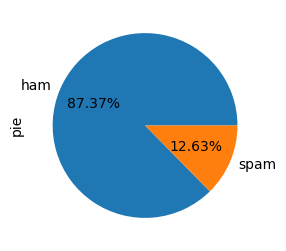

In [ ]:
df['target'].value_counts().plot.pie(autopct='%0.2f%%', figsize=(4, 3), labels=['ham', 'spam'], ylabel='pie')

<Axes: xlabel='target', ylabel='count'>

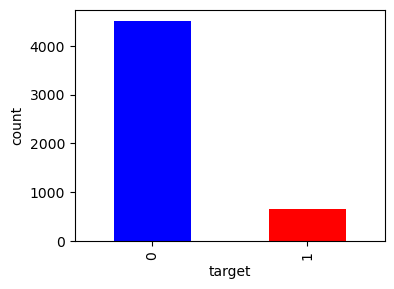

In [ ]:
df['target'].value_counts().plot.bar(color=['blue', 'red'], figsize=(4,3), ylabel='count')

In [ ]:
df['n_ch'] = df['text'].apply(len)
df['n_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['n_sent'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [ ]:
print(df[['n_ch', 'n_words', 'n_sent']].describe())
print(df[df['target']== 0][['n_ch', 'n_words', 'n_sent']].describe())
print(df[df['target']== 1][['n_ch', 'n_words', 'n_sent']].describe())

              n_ch      n_words       n_sent
count  5169.000000  5169.000000  5169.000000
mean     78.977945    18.455794     1.965564
std      58.236293    13.324758     1.448541
min       2.000000     1.000000     1.000000
25%      36.000000     9.000000     1.000000
50%      60.000000    15.000000     1.000000
75%     117.000000    26.000000     2.000000
max     910.000000   220.000000    38.000000
              n_ch      n_words       n_sent
count  4516.000000  4516.000000  4516.000000
mean     70.459256    17.123782     1.820195
std      56.358207    13.493970     1.383657
min       2.000000     1.000000     1.000000
25%      34.000000     8.000000     1.000000
50%      52.000000    13.000000     1.000000
75%      90.000000    22.000000     2.000000
max     910.000000   220.000000    38.000000
             n_ch     n_words      n_sent
count  653.000000  653.000000  653.000000
mean   137.891271   27.667688    2.970904
std     30.137753    7.008418    1.488425
min     13.000000    2

<Axes: xlabel='n_ch', ylabel='Count'>

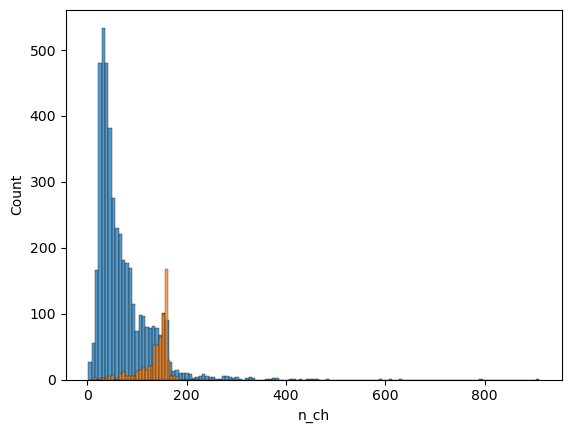

In [ ]:
sns.histplot(df[df['target']== 0]['n_ch'])
sns.histplot(df[df['target']== 1]['n_ch'])

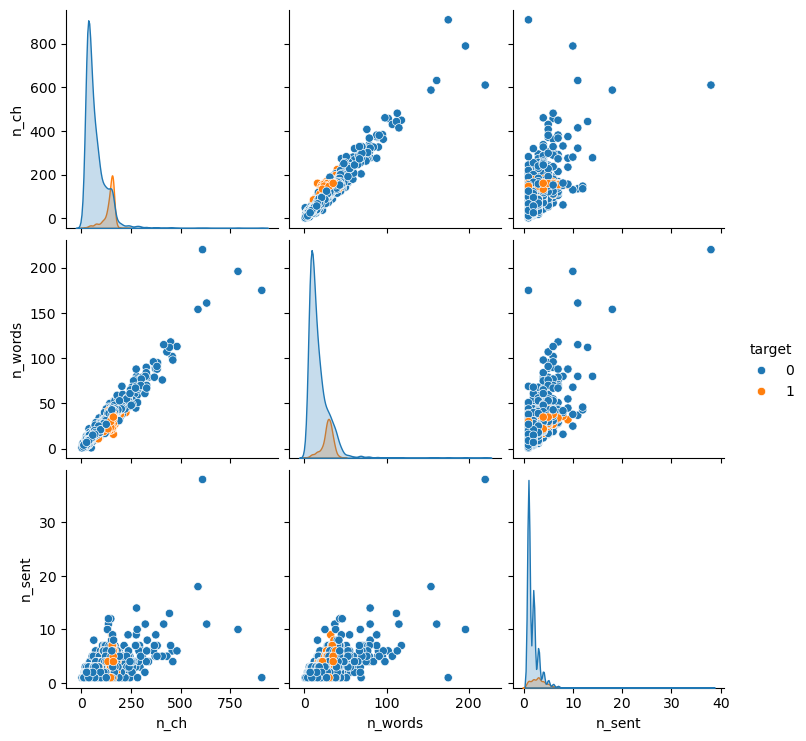

In [ ]:
sns.pairplot(df, hue='target')

<Axes: >

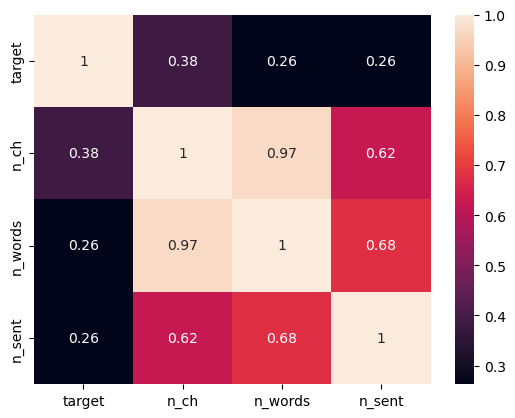

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Results,
    Data is imbalanced(87:13%,0:1)
    new_features - ['n_ch', 'n_words', 'n_sent']

### Text Preprocessing
- Lower case
- Tokenization
- Removing special_ch, stop words, punctuation, html tags
- Stemming

In [11]:
def transform_text(text):
    text = text.lower()

    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()

    ps = PorterStemmer()
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [12]:
df['tr_text'] = df['text'].apply(transform_text)

In [13]:
df['tr_text'].head()

0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri 2 wkli comp win fa cup final tkt 21...
3                  u dun say earli hor u c alreadi say
4                 nah think goe usf live around though
Name: tr_text, dtype: object

### EDA 2

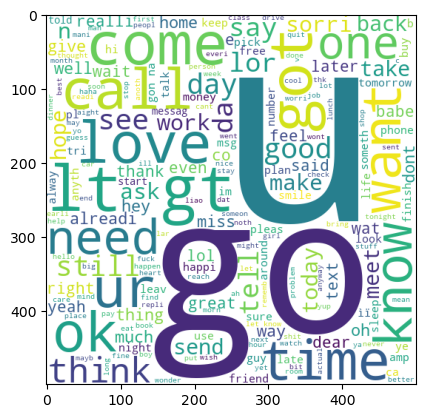

In [ ]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
ham_wc = wc.generate(df[df['target'] == 0]['tr_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

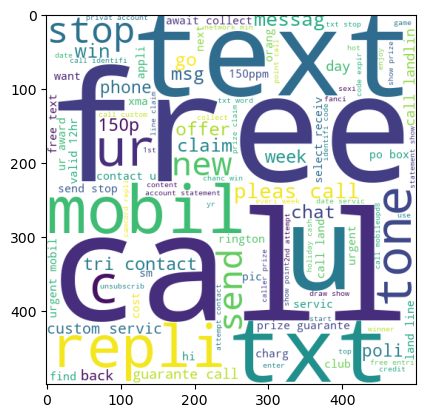

In [ ]:
spam_wc = wc.generate(df[df['target'] == 1]['tr_text'].str.cat(sep=' '))
plt.imshow(spam_wc)

C:\Users\shiva\AppData\Local\Temp\ipykernel_8580\1832215371.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(spam_corpus_df, x=0, y=1, palette='viridis')


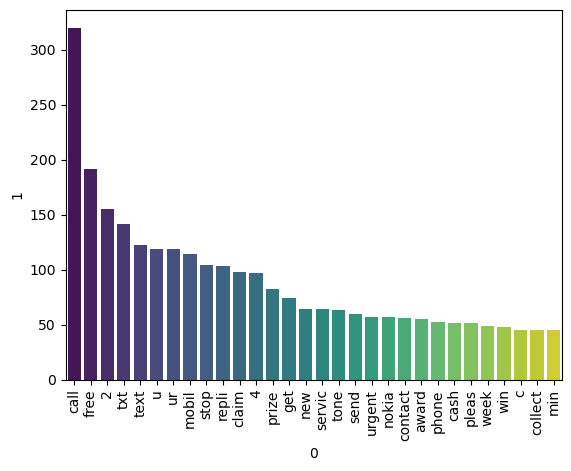

C:\Users\shiva\AppData\Local\Temp\ipykernel_8580\1832215371.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ham_corpus_df, x=0, y=1, palette='viridis')


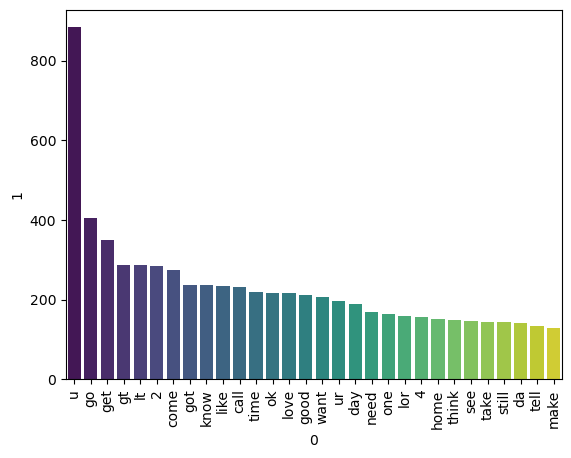

In [ ]:
spam_corpus = []
ham_corpus = []
for msg in df[df['target'] == 1]['tr_text'].to_list():
    for word in msg.split():
        spam_corpus.append(word)
for msg in df[df['target'] == 0]['tr_text'].to_list():
    for word in msg.split():
        ham_corpus.append(word)

spam_corpus_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
ham_corpus_df = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(spam_corpus_df, x=0, y=1, palette='viridis')
plt.xticks(rotation='vertical')
plt.show()

sns.barplot(ham_corpus_df, x=0, y=1, palette='viridis')
plt.xticks(rotation='vertical')
plt.show()

### Model Building

In [ ]:
X = df['tr_text']
y = df['target']

In [ ]:
tfidf = TfidfVectorizer(max_features=3500)
X_tr =  tfidf.fit_transform(X).toarray()

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', p=2, n_jobs=-1)
gnb = GaussianNB()
mnb = MultinomialNB(alpha=1.0)
bnb = BernoulliNB(alpha=1.0)
cnb = CategoricalNB(alpha=1.0)
cmnb = ComplementNB(alpha=1.0)
lr = LogisticRegression(C=1.0, l1_ratio=0.0, n_jobs=-1)
svc = SVC(C=1.0, kernel='rbf', degree=3, gamma='auto')
dt = DecisionTreeClassifier(criterion='gini', max_depth=20, min_impurity_decrease=0.01)
ada = AdaBoostClassifier(estimator=None, n_estimators=50, learning_rate=1.0)
rf = RandomForestClassifier(n_estimators=50, n_jobs=-1)
xg = xgb.XGBClassifier()

def make_pipe(clf):
    return Pipeline([
        # ('tfidf', TfidfVectorizer(max_features=3500)),
        ('clf', clf)
    ])

svc_pipe = Pipeline([
    # ('tfidf', TfidfVectorizer(max_features=3500)),
    ('scaler', StandardScaler()),
    ('clf', svc)
])

d = {
    'KNeighborsClassifier':    make_pipe(knn),
    'GaussianNB':              make_pipe(gnb),
    'MultinomialNB':           make_pipe(mnb),
    'BernoulliNB':             make_pipe(bnb),
    'CategoricalNB':           make_pipe(cnb),
    'ComplementNB':            make_pipe(cmnb),
    'LogisticRegression':      make_pipe(lr),
    'SVC':                     svc_pipe,
    'DecisionTreeClassifier':  make_pipe(dt),
    'AdaBoostClassifier':      make_pipe(ada),
    'RandomForestClassifier':  make_pipe(rf),
    'XGBClassifier':           make_pipe(xg),
}

ven = VotingClassifier(estimators=[
    ('rf', rf), ('mnb', mnb), ('knn', knn), ('svc_pipe', svc_pipe)
], voting='hard', weights=None, n_jobs=-1)
sen = StackingClassifier(estimators=[
    ('rf', rf), ('mnb', mnb), ('knn', knn), ('svc_pipe', svc_pipe)
], final_estimator=lr, stack_method='auto', n_jobs=-1)

d2 = {
    'VotingClassifier':      ven,
    'StackingClassifier':    sen
}

In [ ]:
df_dict = {'model': [], 'Accuracy':[], 'Precision':[]}
for name, model in d.items():
    result = cross_validate(model, X_tr, y, cv=6, scoring=['accuracy', 'precision'])
    acc = result['test_accuracy'].mean()
    pre = result['test_precision'].mean()

    df_dict['model'].append(name)
    df_dict['Accuracy'].append(acc)
    df_dict['Precision'].append(pre)

c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\utils\_response.py", line 214, in _get_response_values
    y_pred = prediction_method(X)
  File "c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\pipeline.py", line 789, in predict
    return self

In [ ]:
model_comp = pd.DataFrame(df_dict)
model_comp.sort_values('Precision', ascending=False)

,model,Accuracy,Precision
7,SVC,0.941188,1.000000
12,VotingClassifier,0.962467,1.000000
2,MultinomialNB,0.972528,0.994186
10,RandomForestClassifier,0.974460,0.990253
0,KNeighborsClassifier,0.911974,0.989247
3,BernoulliNB,0.978718,0.977451
13,StackingClassifier,0.982780,0.973646
6,LogisticRegression,0.956278,0.972282
11,XGBClassifier,0.969238,0.941904
9,AdaBoostClassifier,0.924936,0.817768


In [ ]:
for name, model in d2.items():
    result = cross_validate(model, X_tr, y, cv=6, scoring=['accuracy', 'precision'])
    acc = result['test_accuracy'].mean()
    pre = result['test_precision'].mean()

    df_dict['model'].append(name)
    df_dict['Accuracy'].append(acc)
    df_dict['Precision'].append(pre)

c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\shiva\anaconda3\envs\datasci_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'el

### Final Model

In [44]:
X = df['tr_text']
y = df['target']

tfidf = TfidfVectorizer(max_features=3800)
X_tr =  tfidf.fit_transform(X).toarray()

svc = SVC(C=1.0, kernel='rbf', degree=3, gamma='auto')
svc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', svc)
])
ven = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(n_estimators=100, n_jobs=-1)),
    ('mnb', MultinomialNB(alpha=1.0)), 
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='uniform', p=2, n_jobs=-1)), 
    ('svc_pipe', svc_pipe)
], voting='hard', weights=None, n_jobs=-1)
ven.fit(X_tr, y)

mnb = MultinomialNB(alpha=1.0)
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
mnb.fit(X_tr, y)
rf.fit(X_tr, y)
print()

In [45]:
test = pd.read_csv('dummydata.csv')

In [46]:
test['tr_message'] = test['message'].apply(transform_text)

X_test = test['tr_message']
y_test = test['label']

In [47]:
X_test_tr = tfidf.transform(X_test).toarray()

In [48]:
y_pred1 = ven.predict(X_test_tr)
y_pred2 = mnb.predict(X_test_tr)
y_pred3 = rf.predict(X_test_tr)

print(accuracy_score(y_test, y_pred1), precision_score(y_test, y_pred1))
print(accuracy_score(y_test, y_pred2), precision_score(y_test, y_pred2))
print(accuracy_score(y_test, y_pred3), precision_score(y_test, y_pred3))

0.82 1.0
0.9 0.9523809523809523
0.9 1.0


In [49]:
joblib.dump(rf, 'Model.pkl')
joblib.dump(tfidf, 'text_vector.pkl')

['text_vector.pkl']